# Supply Chain Network Design — Olist Dataset
## Phase 3: MILP Facility Location Optimization

**Problem**: Where should we open Distribution Centers (DCs) across Brazil to minimize total logistics cost while satisfying all demand and meeting service-level constraints?

**Formulation**: Capacitated Facility Location Problem (CFLP)

$$\min \sum_{j} f_j y_j + \sum_{i} \sum_{j} c_{ij} x_{ij}$$

Subject to:
- $\sum_j x_{ij} \geq d_i \quad \forall i$ — demand satisfaction
- $\sum_i x_{ij} \leq K_j y_j \quad \forall j$ — capacity constraint
- $x_{ij} \leq d_i y_j \quad \forall i,j$ — assignment only to open DCs
- $y_j \in \{0,1\}, \quad x_{ij} \geq 0$ — integrality

**Where**:
- $y_j$ = 1 if DC opened at candidate location $j$, 0 otherwise
- $x_{ij}$ = flow (orders) from DC $j$ to demand state $i$
- $f_j$ = fixed opening cost of DC $j$
- $c_{ij}$ = unit transport cost from $j$ to $i$ (distance-based)
- $d_i$ = forecasted demand at state $i$ (from Phase 2 LightGBM)
- $K_j$ = capacity of DC $j$

---
**Prerequisites**: Phase 1 outputs (`demand_nodes.csv`, `distance_matrix_km.csv`) + Phase 2 output (`demand_for_milp.csv`)

## 0. Imports & Configuration

In [36]:
# !pip install pulp pandas numpy matplotlib seaborn folium

In [37]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import folium
from folium.plugins import AntPath
import pulp

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.2f}".format)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

# ── Paths ──────────────────────────────────────────────────────────────
OUTPUT_DIR = "C:\M2 SPA\Supply Chain\outputs"

# ── Cost parameters (calibrated to Olist freight data) ────────────────
COST_PER_KM_PER_ORDER = 0.08    # BRL per km per order (from avg freight / avg distance)
MAX_SERVICE_DISTANCE  = 3500    # km — max allowed DC-to-state distance
DC_CAPACITY_FACTOR    = 8.0     # DC can serve up to 3x the average state demand

# Fixed opening costs by DC tier (BRL/month, realistic Brazilian logistics)
# Tier 1 = major hub (SP, RJ), Tier 2 = regional, Tier 3 = small
DC_FIXED_COSTS = {
    "SP": 150_000, "RJ": 130_000, "MG": 110_000, "RS": 100_000,
    "PR": 100_000, "SC":  90_000, "BA":  85_000, "GO":  80_000,
    "PE":  75_000, "CE":  75_000, "ES":  70_000, "MT":  65_000,
    "MS":  65_000, "MA":  60_000, "PA":  60_000, "DF":  80_000,
    "RN":  55_000, "PI":  50_000, "PB":  50_000, "AL":  50_000,
    "TO":  45_000, "SE":  45_000, "RO":  45_000, "AM":  55_000,
    "AP":  40_000, "AC":  40_000, "RR":  40_000,
}

print("✅ Imports OK")
print(f"   PuLP version : {pulp.__version__}")
print(f"   Solver       : CBC (default)")

✅ Imports OK
   PuLP version : 3.0.2
   Solver       : CBC (default)


## 1. Load Data from Phase 1 & Phase 2

In [38]:
# ── Demand nodes (LightGBM forecasts + coordinates) ────────────────────
demand_df = pd.read_csv(f"{OUTPUT_DIR}/demand_for_milp.csv")
demand_df = demand_df.dropna(subset=["centroid_lat", "centroid_lng"])
demand_df = demand_df[demand_df["total_forecast"] > 0].copy()
demand_df.reset_index(drop=True, inplace=True)

# ── Distance matrix (km between state centroids, from Phase 1) ─────────
dist_raw = pd.read_csv(f"{OUTPUT_DIR}/distance_matrix_km.csv", index_col=0)

# ── Supply nodes (sellers by state, from Phase 1) ──────────────────────
supply_df = pd.read_csv(f"{OUTPUT_DIR}/supply_nodes.csv")

print(f"Demand nodes loaded : {len(demand_df)} states")
print(f"Distance matrix     : {dist_raw.shape}")
print(f"Supply nodes loaded : {len(supply_df)} states")
print(f"\nTotal forecasted demand (3 months): {demand_df['total_forecast'].sum():,.0f} orders")
print(f"\nDemand snapshot:")
demand_df[["demand_state", "total_forecast", "total_lower_95",
           "total_upper_95", "demand_share_%"]].head(10)

Demand nodes loaded : 27 states
Distance matrix     : (27, 27)
Supply nodes loaded : 22 states

Total forecasted demand (3 months): 30,038 orders

Demand snapshot:


,demand_state,total_forecast,total_lower_95,total_upper_95,demand_share_%
0,SP,12124.49,10917.93,13318.26,40.36
1,RJ,3998.18,3383.55,4640.64,13.31
2,MG,3647.62,3168.28,4153.08,12.14
3,RS,1759.45,1478.42,2034.28,5.86
4,PR,1497.01,1317.26,1676.85,4.98
5,SC,1136.66,941.92,1329.04,3.78
6,BA,1071.87,946.68,1200.03,3.57
7,ES,679.20,574.84,789.83,2.26
8,GO,653.99,540.62,760.49,2.18
9,DF,537.06,530.70,542.95,1.79


## 2. Build Model Parameters

In [39]:
# ── Index sets ─────────────────────────────────────────────────────────
# I = demand states (customers)
# J = candidate DC locations (all states are candidates)
I = demand_df["demand_state"].tolist()          # demand nodes
J = [s for s in DC_FIXED_COSTS if s in dist_raw.index]  # candidate DCs

print(f"Demand nodes  |I| = {len(I)}")
print(f"Candidate DCs |J| = {len(J)}")

# ── Demand d_i ─────────────────────────────────────────────────────────
d = dict(zip(demand_df["demand_state"], demand_df["total_forecast"]))
d_lower = dict(zip(demand_df["demand_state"], demand_df["total_lower_95"]))
d_upper = dict(zip(demand_df["demand_state"], demand_df["total_upper_95"]))

# ── Fixed costs f_j ────────────────────────────────────────────────────
f = {j: DC_FIXED_COSTS[j] for j in J}

# ── Transport cost c_ij = cost_per_km × distance(i,j) ──────────────────
# Fill missing distances with a large penalty
MAX_DIST_PENALTY = 9999
c = {}
for i in I:
    for j in J:
        if i in dist_raw.index and j in dist_raw.columns:
            dist = dist_raw.loc[i, j]
            c[(i, j)] = COST_PER_KM_PER_ORDER * float(dist)
        else:
            c[(i, j)] = MAX_DIST_PENALTY

# ── Capacity K_j ───────────────────────────────────────────────────────
avg_demand = np.mean(list(d.values()))
total_demand = sum(d.values())
K = {j: total_demand * DC_CAPACITY_FACTOR / len(J) for j in J}
print(f"Total demand      : {total_demand:,.0f}")
print(f"Total capacity    : {sum(K.values()):,.0f}  (ratio: {sum(K.values())/total_demand:.1f}x)")

# ── Service level: forbidden assignments (distance > MAX_SERVICE_DISTANCE)
forbidden = set()
for i in I:
    for j in J:
        if i in dist_raw.index and j in dist_raw.columns:
            if float(dist_raw.loc[i, j]) > MAX_SERVICE_DISTANCE:
                forbidden.add((i, j))

print(f"\nAvg DC capacity     : {avg_demand * DC_CAPACITY_FACTOR * len(I) / len(J):,.0f} orders")
print(f"Forbidden routes    : {len(forbidden)} (exceed {MAX_SERVICE_DISTANCE} km)")
print(f"\nFixed cost range    : R${min(f.values()):,} – R${max(f.values()):,} / month")
print(f"Transport cost range: R${min(c.values()):.2f} – R${max(c.values()):.2f} / order")

Demand nodes  |I| = 27
Candidate DCs |J| = 27
Total demand      : 30,038
Total capacity    : 240,305  (ratio: 8.0x)

Avg DC capacity     : 8,900 orders
Forbidden routes    : 12 (exceed 3500 km)

Fixed cost range    : R$40,000 – R$150,000 / month
Transport cost range: R$0.00 – R$301.86 / order


## 3. MILP Solver Function

In [40]:
def solve_cflp(I, J, d, f, c, K, forbidden=set(),
               max_dcs=None, min_dcs=None,
               name="CFLP", time_limit=120):
    """
    Solve the Capacitated Facility Location Problem.

    Parameters
    ----------
    I         : list of demand node ids
    J         : list of candidate DC location ids
    d         : dict {i: demand}
    f         : dict {j: fixed opening cost}
    c         : dict {(i,j): unit transport cost}
    K         : dict {j: capacity}
    forbidden : set of (i,j) pairs not allowed
    max_dcs   : optional upper bound on number of open DCs
    min_dcs   : optional lower bound on number of open DCs
    name      : problem name
    time_limit: solver time limit in seconds

    Returns
    -------
    dict with status, objective, open_dcs, flows, metrics
    """
    prob = pulp.LpProblem(name, pulp.LpMinimize)

    # ── Decision variables ─────────────────────────────────────────────
    y = pulp.LpVariable.dicts("open", J, cat="Binary")
    x = pulp.LpVariable.dicts("flow", [(i, j) for i in I for j in J],
                               lowBound=0, cat="Continuous")

    # ── Objective: minimize fixed + transport cost ─────────────────────
    prob += (
        pulp.lpSum(f[j] * y[j] for j in J) +
        pulp.lpSum(c[(i, j)] * x[(i, j)] for i in I for j in J
                   if (i, j) not in forbidden)
    ), "Total_Cost"

    # ── Constraints ────────────────────────────────────────────────────

    # C1: Demand satisfaction — all demand must be fulfilled
    for i in I:
        prob += (
            pulp.lpSum(x[(i, j)] for j in J if (i, j) not in forbidden)
            >= d[i]
        ), f"Demand_{i}"

    # C2: Capacity — DC can only serve up to its capacity if open
    for j in J:
        prob += (
            pulp.lpSum(x[(i, j)] for i in I if (i, j) not in forbidden)
            <= K[j] * y[j]
        ), f"Capacity_{j}"

    # C3: Linking — can only send flow to open DCs
    for i in I:
        for j in J:
            if (i, j) not in forbidden:
                prob += x[(i, j)] <= d[i] * y[j], f"Link_{i}_{j}"

    # C4: Forbidden routes — zero flow on infeasible routes
    for (i, j) in forbidden:
        prob += x[(i, j)] == 0, f"Forbidden_{i}_{j}"

    # C5: Max / min DC count constraints (optional)
    if max_dcs is not None:
        prob += pulp.lpSum(y[j] for j in J) <= max_dcs, "MaxDCs"
    if min_dcs is not None:
        prob += pulp.lpSum(y[j] for j in J) >= min_dcs, "MinDCs"

    # ── Solve ──────────────────────────────────────────────────────────
    solver = pulp.PULP_CBC_CMD(
        timeLimit=time_limit,
        msg=0,              # suppress CBC output
        gapRel=0.01,        # stop at 1% optimality gap
    )
    prob.solve(solver)

    # ── Extract results ────────────────────────────────────────────────
    status     = pulp.LpStatus[prob.status]
    obj        = pulp.value(prob.objective)
    open_dcs   = [j for j in J if pulp.value(y[j]) > 0.5]
    flows      = {
        (i, j): pulp.value(x[(i, j)])
        for i in I for j in J
        if (i, j) not in forbidden and pulp.value(x[(i, j)]) > 0.01
    }

    # Assignment: which DC serves each demand state
    assignment = {}
    for i in I:
        best_j = max(
            [j for j in open_dcs if (i, j) not in forbidden],
            key=lambda j: flows.get((i, j), 0),
            default=None
        )
        assignment[i] = best_j

    # Costs breakdown
    fixed_cost     = sum(f[j] for j in open_dcs)
    transport_cost = sum(c[(i, j)] * v for (i, j), v in flows.items())

    # Utilization per DC
    utilization = {}
    for j in open_dcs:
        served = sum(flows.get((i, j), 0) for i in I)
        utilization[j] = served / K[j] * 100

    # Weighted average distance
    total_orders = sum(d[i] for i in I)
    avg_dist = sum(
        flows.get((i, j), 0) * float(dist_raw.loc[i, j])
        for i in I for j in open_dcs
        if i in dist_raw.index and j in dist_raw.columns
        and (i, j) not in forbidden
    ) / max(total_orders, 1)

    return {
        "status"         : status,
        "objective"      : obj,
        "open_dcs"       : open_dcs,
        "flows"          : flows,
        "assignment"     : assignment,
        "fixed_cost"     : fixed_cost,
        "transport_cost" : transport_cost,
        "utilization"    : utilization,
        "avg_dist_km"    : avg_dist,
        "n_dcs"          : len(open_dcs),
        "problem"        : prob,
    }

print("✅ MILP solver function defined")

✅ MILP solver function defined


## 4. Baseline Solution — Unconstrained Optimal

In [41]:
print("Solving baseline CFLP (no DC count constraint) …")

baseline = solve_cflp(I, J, d, f, c, K, forbidden=forbidden, name="CFLP_Baseline")

print(f"\n{'='*50}")
print(f"  STATUS          : {baseline['status']}")
print(f"  Total cost      : R$ {baseline['objective']:>12,.0f}")
print(f"  Fixed cost      : R$ {baseline['fixed_cost']:>12,.0f}")
print(f"  Transport cost  : R$ {baseline['transport_cost']:>12,.0f}")
print(f"  DCs opened      : {baseline['n_dcs']} / {len(J)} candidates")
print(f"  Open DCs        : {sorted(baseline['open_dcs'])}")
print(f"  Avg distance    : {baseline['avg_dist_km']:.0f} km")
print(f"{'='*50}")

print("\nDC Utilization:")
util_df = pd.DataFrame([
    {"DC": j, "Utilization %": round(v, 1),
     "Orders Served": sum(baseline["flows"].get((i, j), 0) for i in I)}
    for j, v in baseline["utilization"].items()
]).sort_values("Utilization %", ascending=False)
print(util_df.to_string(index=False))

Solving baseline CFLP (no DC count constraint) …

  STATUS          : Optimal
  Total cost      : R$    1,011,446
  Fixed cost      : R$      575,000
  Transport cost  : R$      436,446
  DCs opened      : 6 / 27 candidates
  Open DCs        : ['MG', 'PI', 'RJ', 'SC', 'SE', 'SP']
  Avg distance    : 182 km

DC Utilization:
DC  Utilization %  Orders Served
SP         100.00        8900.18
RJ          81.10        7222.49
MG          65.50        5825.80
SC          52.80        4699.98
SE          23.40        2082.13
PI          14.70        1307.51


In [42]:
# ── Assignment table: which DC serves which state ──────────────────────
assignment_df = pd.DataFrame([
    {
        "Demand State"  : i,
        "Served by DC"  : baseline["assignment"].get(i, "N/A"),
        "Orders"        : round(d[i], 0),
        "Distance (km)" : round(float(dist_raw.loc[i, baseline["assignment"][i]])
                               if baseline["assignment"].get(i) else 0, 0),
        "Transport Cost": round(c.get((i, baseline["assignment"].get(i, J[0])), 0) * d[i], 0),
    }
    for i in I
]).sort_values("Orders", ascending=False)

print("\nAssignment — Demand State → DC:")
assignment_df


Assignment — Demand State → DC:


,Demand State,Served by DC,Orders,Distance (km),Transport Cost
0,SP,SP,12124.00,0.00,0.00
1,RJ,RJ,3998.00,0.00,0.00
2,MG,MG,3648.00,0.00,0.00
3,RS,SC,1759.00,374.00,52681.00
4,PR,SC,1497.00,230.00,27528.00
5,SC,SC,1137.00,0.00,0.00
6,BA,SE,1072.00,290.00,24876.00
7,ES,MG,679.00,385.00,20902.00
8,GO,MG,654.00,663.00,34710.00
9,DF,MG,537.00,621.00,26680.00


## 5. Sensitivity Analysis — Varying Number of DCs

In [43]:
print("Running sensitivity analysis: 1 to 8 DCs …\n")

sensitivity_results = []

for n in range(1, 9):
    result = solve_cflp(
        I, J, d, f, c, K,
        forbidden=forbidden,
        max_dcs=n, min_dcs=n,
        name=f"CFLP_{n}DCs"
    )
    if result["objective"] is not None:
        sensitivity_results.append({
            "n_dcs"          : n,
            "status"         : result["status"],
            "total_cost"     : result["objective"],
            "fixed_cost"     : result["fixed_cost"],
            "transport_cost" : result["transport_cost"],
            "avg_dist_km"    : result["avg_dist_km"],
            "open_dcs"       : ", ".join(sorted(result["open_dcs"])),
        })
        print(f"  {n} DC(s) → Cost: R${result['objective']:>10,.0f} "
              f"| Avg dist: {result['avg_dist_km']:>5.0f} km "
              f"| Open: {sorted(result['open_dcs'])}")

sens_df = pd.DataFrame(sensitivity_results)
print("\n✅ Sensitivity analysis complete")

Running sensitivity analysis: 1 to 8 DCs …

  1 DC(s) → Cost: R$ 8,191,386 | Avg dist:  3314 km | Open: ['RR']
  2 DC(s) → Cost: R$ 5,182,329 | Avg dist:  1914 km | Open: ['RR']
  3 DC(s) → Cost: R$ 2,327,961 | Avg dist:   223 km | Open: ['MG', 'PR', 'SP']
  4 DC(s) → Cost: R$ 1,047,485 | Avg dist:   267 km | Open: ['MG', 'PR', 'SE', 'SP']
  5 DC(s) → Cost: R$ 1,025,710 | Avg dist:   208 km | Open: ['MG', 'RJ', 'SC', 'SE', 'SP']
  6 DC(s) → Cost: R$ 1,011,446 | Avg dist:   182 km | Open: ['MG', 'PI', 'RJ', 'SC', 'SE', 'SP']
  7 DC(s) → Cost: R$ 1,011,545 | Avg dist:   148 km | Open: ['GO', 'MG', 'PI', 'RJ', 'SC', 'SE', 'SP']
  8 DC(s) → Cost: R$ 1,037,284 | Avg dist:   142 km | Open: ['AP', 'GO', 'MG', 'PB', 'RJ', 'SC', 'SE', 'SP']

✅ Sensitivity analysis complete


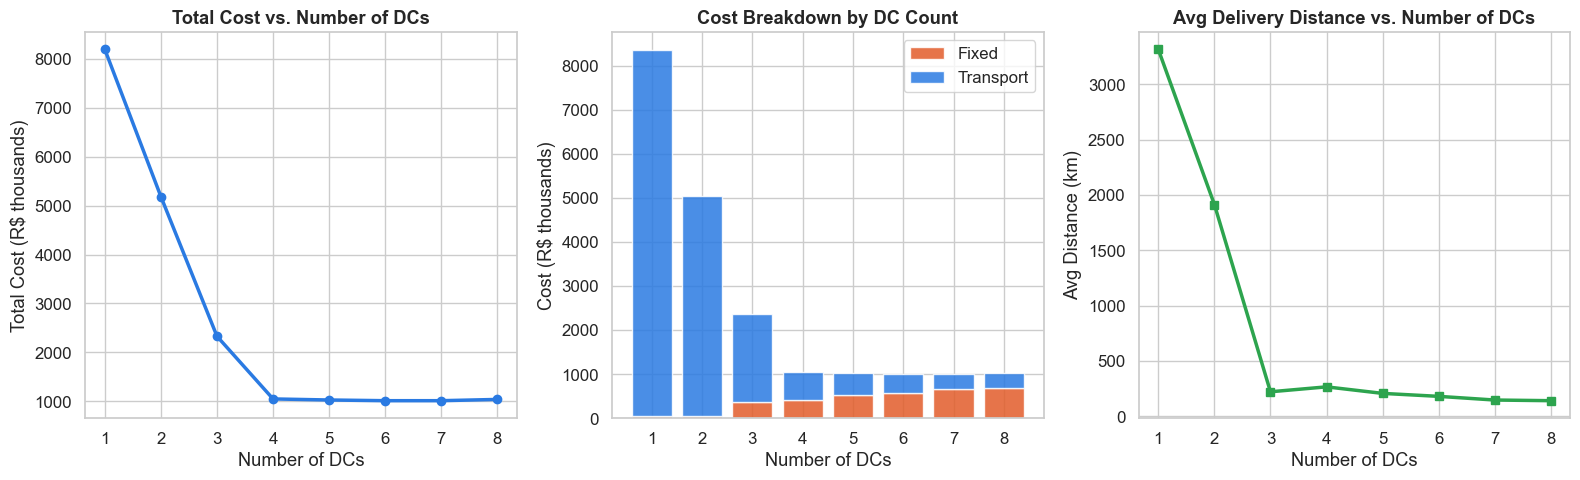

✅ Saved: 16_sensitivity_analysis.png


In [44]:
# ── Sensitivity plots ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Total cost curve
axes[0].plot(sens_df["n_dcs"], sens_df["total_cost"] / 1000,
             marker="o", linewidth=2.5, color="#2a7ae2")
axes[0].set_title("Total Cost vs. Number of DCs", fontweight="bold")
axes[0].set_xlabel("Number of DCs")
axes[0].set_ylabel("Total Cost (R$ thousands)")
axes[0].xaxis.set_major_locator(plt.MaxNLocator(integer=True))

# Cost breakdown stacked bar
axes[1].bar(sens_df["n_dcs"], sens_df["fixed_cost"] / 1000,
            label="Fixed", color="#e25c2a", alpha=0.85)
axes[1].bar(sens_df["n_dcs"], sens_df["transport_cost"] / 1000,
            bottom=sens_df["fixed_cost"] / 1000,
            label="Transport", color="#2a7ae2", alpha=0.85)
axes[1].set_title("Cost Breakdown by DC Count", fontweight="bold")
axes[1].set_xlabel("Number of DCs")
axes[1].set_ylabel("Cost (R$ thousands)")
axes[1].legend()
axes[1].xaxis.set_major_locator(plt.MaxNLocator(integer=True))

# Average distance curve
axes[2].plot(sens_df["n_dcs"], sens_df["avg_dist_km"],
             marker="s", linewidth=2.5, color="#2da44e")
axes[2].set_title("Avg Delivery Distance vs. Number of DCs", fontweight="bold")
axes[2].set_xlabel("Number of DCs")
axes[2].set_ylabel("Avg Distance (km)")
axes[2].xaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/16_sensitivity_analysis.png", dpi=150)
plt.show()
print("✅ Saved: 16_sensitivity_analysis.png")

In [45]:
# ── Elbow point: marginal cost reduction ──────────────────────────────
sens_df["marginal_saving"] = sens_df["total_cost"].diff(-1).fillna(0)
sens_df["marginal_saving_%"] = (
    sens_df["marginal_saving"] / sens_df["total_cost"].shift(1) * 100
).fillna(0).round(1)

print("Marginal cost savings from adding each DC:\n")
print(sens_df[["n_dcs", "total_cost", "marginal_saving",
               "marginal_saving_%", "avg_dist_km"]].to_string(index=False))

costs   = sens_df["total_cost"].values
n_range = sens_df["n_dcs"].values

# Normalize and compute curvature
x_norm = (n_range - n_range.min()) / (n_range.max() - n_range.min())
y_norm = (costs   - costs.min())   / (costs.max()   - costs.min())
curvature = np.diff(np.diff(y_norm))  # second derivative
elbow_idx = np.argmax(curvature) + 2  # +2 because of two diffs
elbow     = int(n_range[elbow_idx])

print(f"\n📌 Recommended number of DCs (elbow point): {elbow}")
print(f"   Total cost at elbow: R$ {sens_df[sens_df['n_dcs']==elbow]['total_cost'].values[0]:,.0f}")
print(f"   Avg distance       : {sens_df[sens_df['n_dcs']==elbow]['avg_dist_km'].values[0]:.0f} km")

Marginal cost savings from adding each DC:

 n_dcs  total_cost  marginal_saving  marginal_saving_%  avg_dist_km
     1  8191386.33       3009057.00               0.00      3313.89
     2  5182329.33       2854368.69              34.80      1913.88
     3  2327960.64       1280475.99              24.70       222.89
     4  1047484.64         21774.82               0.90       267.36
     5  1025709.83         14263.64               1.40       208.36
     6  1011446.19           -98.83              -0.00       181.62
     7  1011545.03        -25738.59              -2.50       148.37
     8  1037283.62             0.00               0.00       142.44

📌 Recommended number of DCs (elbow point): 4
   Total cost at elbow: R$ 1,047,485
   Avg distance       : 267 km


## 6. Stochastic Scenario Analysis

In [46]:
# ── Three demand scenarios using Phase 2 uncertainty bounds ────────────
# Pessimistic  → d_lower  (Prophet lower 95% CI)
# Baseline     → d        (LightGBM point forecast)
# Optimistic   → d_upper  (Prophet upper 95% CI)

scenarios = {
    "Pessimistic (lower 95%)": d_lower,
    "Baseline (LightGBM)"    : d,
    "Optimistic (upper 95%)" : d_upper,
}

scenario_results = {}
print("Solving CFLP for 3 demand scenarios …\n")

for scenario_name, demand_scenario in scenarios.items():
    # Clamp demand to 0
    d_clean = {i: max(v, 0) for i, v in demand_scenario.items() if i in I}

    result = solve_cflp(
        I, J, d_clean, f, c, K,
        forbidden=forbidden,
        max_dcs=int(elbow),
        min_dcs=None,
        name=f"CFLP_{scenario_name[:4].strip()}"
    )
    scenario_results[scenario_name] = result
    print(f"  {scenario_name}")
    print(f"    Status      : {result['status']}")
    print(f"    Total cost  : R$ {result['objective']:>10,.0f}")
    print(f"    Open DCs    : {sorted(result['open_dcs'])}")
    print(f"    Avg distance: {result['avg_dist_km']:.0f} km\n")

print("✅ Scenario analysis complete")

Solving CFLP for 3 demand scenarios …

  Pessimistic (lower 95%)
    Status      : Optimal
    Total cost  : R$    915,065
    Open DCs    : ['MG', 'SC', 'SE', 'SP']
    Avg distance: 247 km

  Baseline (LightGBM)
    Status      : Optimal
    Total cost  : R$  1,047,485
    Open DCs    : ['MG', 'PR', 'SE', 'SP']
    Avg distance: 267 km

  Optimistic (upper 95%)
    Status      : Optimal
    Total cost  : R$  1,325,650
    Open DCs    : ['BA', 'RJ', 'SC', 'SP']
    Avg distance: 322 km

✅ Scenario analysis complete


In [47]:
# ── Scenario comparison table ──────────────────────────────────────────
scenario_table = pd.DataFrame([
    {
        "Scenario"      : name,
        "Total Cost"    : f"R$ {res['objective']:,.0f}",
        "Fixed Cost"    : f"R$ {res['fixed_cost']:,.0f}",
        "Transport Cost": f"R$ {res['transport_cost']:,.0f}",
        "Avg Dist (km)" : f"{res['avg_dist_km']:.0f}",
        "Open DCs"      : ", ".join(sorted(res["open_dcs"])),
        "N DCs"         : res["n_dcs"],
    }
    for name, res in scenario_results.items()
])
scenario_table

,Scenario,Total Cost,Fixed Cost,Transport Cost,Avg Dist (km),Open DCs,N DCs
0,Pessimistic (lower 95%),"R$ 915,065","R$ 395,000","R$ 520,065",247,"MG, SC, SE, SP",4
1,Baseline (LightGBM),"R$ 1,047,485","R$ 405,000","R$ 642,485",267,"MG, PR, SE, SP",4
2,Optimistic (upper 95%),"R$ 1,325,650","R$ 455,000","R$ 870,650",322,"BA, RJ, SC, SP",4


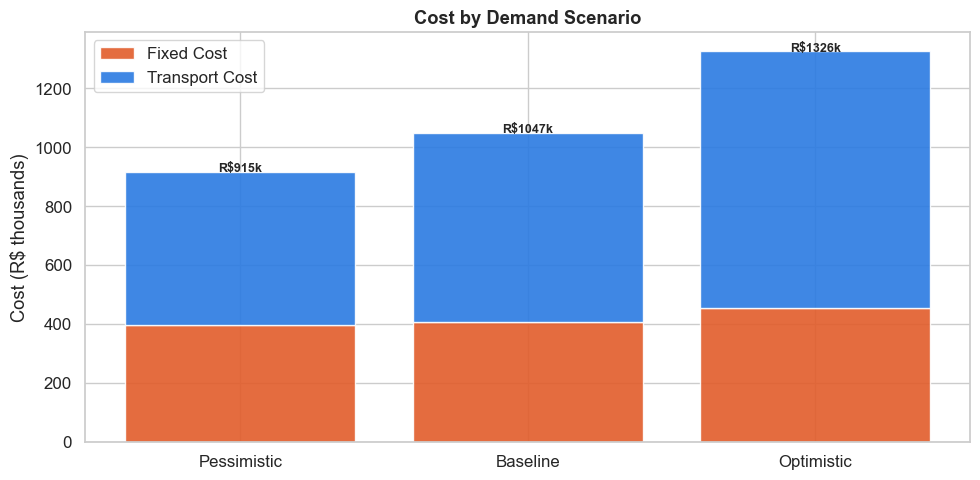

✅ Saved: 17_scenario_comparison.png


In [48]:
# ── Scenario cost comparison bar chart ────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
labels  = list(scenario_results.keys())
fixed_c = [scenario_results[s]["fixed_cost"] / 1000 for s in labels]
trans_c = [scenario_results[s]["transport_cost"] / 1000 for s in labels]

x = np.arange(len(labels))
ax.bar(x, fixed_c, label="Fixed Cost", color="#e25c2a", alpha=0.9)
ax.bar(x, trans_c, bottom=fixed_c, label="Transport Cost", color="#2a7ae2", alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels([l.split("(")[0].strip() for l in labels], rotation=0)
ax.set_title("Cost by Demand Scenario", fontweight="bold")
ax.set_ylabel("Cost (R$ thousands)")
ax.legend()

# Add value labels
for i, (fc, tc) in enumerate(zip(fixed_c, trans_c)):
    ax.text(i, fc + tc + 1, f"R${(fc+tc):.0f}k",
            ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/17_scenario_comparison.png", dpi=150)
plt.show()
print("✅ Saved: 17_scenario_comparison.png")

## 7. Tornado Diagram — Sensitivity to Cost Parameters

In [49]:
# ── One-at-a-time sensitivity on key parameters ────────────────────────
BASE_COST   = baseline["objective"]
BASE_CONFIG = dict(I=I, J=J, d=d, f=f, c=c, K=K, forbidden=forbidden)

def perturb_solve(param, delta, base_config):
    """Solve CFLP with one parameter perturbed by delta (multiplicative)."""
    cfg = dict(base_config)
    if param == "transport_cost":
        cfg["c"] = {k: v * delta for k, v in base_config["c"].items()}
    elif param == "fixed_cost":
        cfg["f"] = {k: v * delta for k, v in base_config["f"].items()}
    elif param == "demand":
        cfg["d"] = {k: v * delta for k, v in base_config["d"].items()}
    elif param == "capacity":
        cfg["K"] = {k: v * delta for k, v in base_config["K"].items()}
    result = solve_cflp(**cfg, name=f"Perturb_{param}_{delta}")
    return result["objective"]

perturbation = 0.20  # ±20%
params       = ["transport_cost", "fixed_cost", "demand", "capacity"]
tornado_data = []

for param in params:
    cost_low  = perturb_solve(param, 1 - perturbation, BASE_CONFIG)
    cost_high = perturb_solve(param, 1 + perturbation, BASE_CONFIG)
    tornado_data.append({
        "Parameter"  : param.replace("_", " ").title(),
        "Low (−20%)" : cost_low,
        "High (+20%)": cost_high,
        "Low Δ"      : cost_low  - BASE_COST,
        "High Δ"     : cost_high - BASE_COST,
        "Range"      : abs(cost_high - cost_low),
    })

tornado_df = pd.DataFrame(tornado_data).sort_values("Range", ascending=True)
tornado_df[["Parameter", "Low (−20%)", "High (+20%)", "Range"]]

,Parameter,Low (−20%),High (+20%),Range
3,Capacity,1078635.35,950692.36,127942.99
0,Transport Cost,912724.07,1082854.03,170129.96
1,Fixed Cost,880545.03,1118905.09,238360.06
2,Demand,836290.19,1147188.92,310898.73


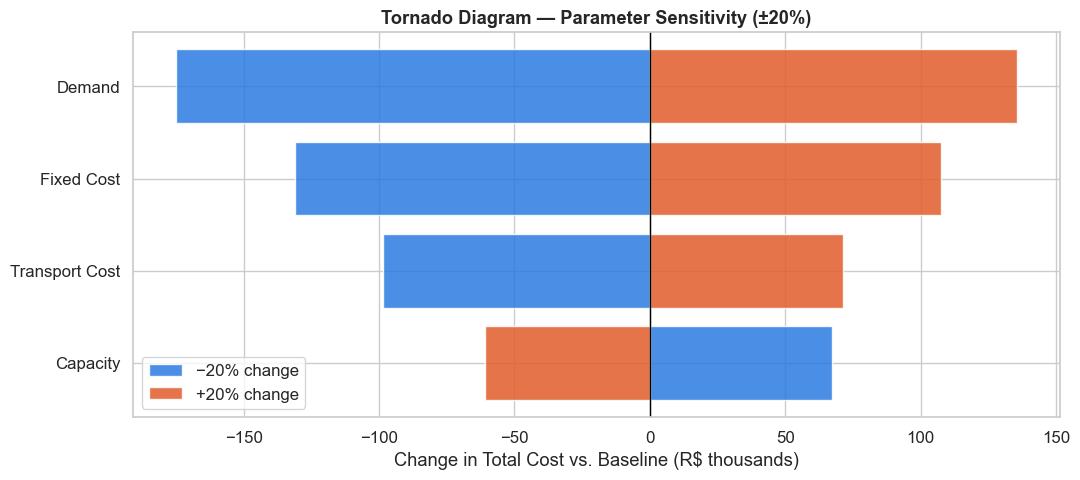

✅ Saved: 18_tornado_diagram.png


In [50]:
# ── Tornado diagram ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

y_pos = range(len(tornado_df))
ax.barh(y_pos, tornado_df["Low Δ"] / 1000,
        left=0, color="#2a7ae2", alpha=0.85, label="−20% change")
ax.barh(y_pos, tornado_df["High Δ"] / 1000,
        left=0, color="#e25c2a", alpha=0.85, label="+20% change")

ax.set_yticks(y_pos)
ax.set_yticklabels(tornado_df["Parameter"])
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Change in Total Cost vs. Baseline (R$ thousands)")
ax.set_title("Tornado Diagram — Parameter Sensitivity (±20%)", fontweight="bold")
ax.legend()

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/18_tornado_diagram.png", dpi=150)
plt.show()
print("✅ Saved: 18_tornado_diagram.png")

## 8. Interactive Network Map

In [51]:
def build_network_map(result, demand_df, dist_raw, title="Supply Chain Network"):
    """Build an interactive Folium map of the optimal DC network."""

    # State centroid lookup
    coords = demand_df.set_index("demand_state")[["centroid_lat", "centroid_lng"]].to_dict("index")

    # Add any DC states missing from demand_df using dist_raw index
    supply_coords = pd.read_csv(f"{OUTPUT_DIR}/supply_nodes.csv")\
        .set_index("state")[["centroid_lat", "centroid_lng"]].to_dict("index")
    for j in result["open_dcs"]:
        if j not in coords and j in supply_coords:
            coords[j] = supply_coords[j]

    m = folium.Map(location=[-14.2, -51.9], zoom_start=4,
                   tiles="CartoDB positron")

    # Color map: each DC gets a distinct color
    dc_colors = ["#e25c2a", "#2a7ae2", "#2da44e", "#9b59b6",
                 "#f39c12", "#1abc9c", "#e74c3c", "#3498db"]
    dc_color  = {j: dc_colors[k % len(dc_colors)]
                 for k, j in enumerate(result["open_dcs"])}

    # Draw flow lines (demand state → serving DC)
    for i in I:
        j = result["assignment"].get(i)
        if j is None or i not in coords or j not in coords:
            continue
        ci, cj = coords[i], coords[j]
        if i == j:
            continue
        flow_vol = result["flows"].get((i, j), 0)
        weight   = 1 + flow_vol / max(result["flows"].values(), default=1) * 5
        folium.PolyLine(
            locations=[[ci["centroid_lat"], ci["centroid_lng"]],
                       [cj["centroid_lat"], cj["centroid_lng"]]],
            weight=weight,
            color=dc_color.get(j, "#888"),
            opacity=0.55,
            tooltip=(
                f"{i} → DC {j}<br>"
                f"Flow: {flow_vol:.0f} orders<br>"
                f"Dist: {float(dist_raw.loc[i,j]):.0f} km<br>"
                f"Cost: R${c.get((i,j),0)*flow_vol:,.0f}"
            ),
        ).add_to(m)

    # Draw demand state markers (small circles)
    for i in I:
        if i not in coords:
            continue
        j    = result["assignment"].get(i)
        col  = dc_color.get(j, "#888")
        ci   = coords[i]
        folium.CircleMarker(
            location=[ci["centroid_lat"], ci["centroid_lng"]],
            radius=5 + d.get(i, 0) / max(d.values()) * 12,
            color=col, fill=True, fill_opacity=0.6,
            popup=folium.Popup(
                f"<b>Demand: {i}</b><br>"
                f"Orders: {d.get(i,0):,.0f}<br>"
                f"Served by DC: {j}",
                max_width=180,
            ),
            tooltip=f"{i} | {d.get(i,0):,.0f} orders → DC {j}",
        ).add_to(m)

    # Draw DC markers (large stars)
    for j in result["open_dcs"]:
        if j not in coords:
            continue
        cj   = coords[j]
        util = result["utilization"].get(j, 0)
        folium.Marker(
            location=[cj["centroid_lat"], cj["centroid_lng"]],
            icon=folium.Icon(color="red" if util > 80 else "blue",
                             icon="industry", prefix="fa"),
            popup=folium.Popup(
                f"<b>DC: {j}</b><br>"
                f"Fixed cost: R${f[j]:,.0f}/mo<br>"
                f"Utilization: {util:.1f}%<br>"
                f"Capacity: {K[j]:,.0f} orders",
                max_width=200,
            ),
            tooltip=f"DC {j} | Util: {util:.0f}%",
        ).add_to(m)

    # Legend
    legend_items = "".join(
        f'<span style="color:{dc_color[j]}">■</span> DC {j}<br>'
        for j in result["open_dcs"]
    )
    legend_html = f"""
    <div style="position:fixed;bottom:30px;left:30px;z-index:999;
         background:white;padding:12px 16px;border-radius:8px;
         border:1px solid #ccc;font-family:Arial;font-size:12px;line-height:2;">
      <b>{title}</b><br>
      {legend_items}
      <hr style="margin:4px 0">
      <span>● Demand state (sized by demand)</span><br>
      <span>⬤ DC location (red = high utilization)</span>
    </div>
    """
    m.get_root().html.add_child(folium.Element(legend_html))
    return m


# Build and save baseline map
m = build_network_map(baseline, demand_df, dist_raw,
                      title=f"Optimal Network — {baseline['n_dcs']} DCs (Baseline)")
m.save(f"{OUTPUT_DIR}/network_map_baseline.html")
print("✅ Saved: network_map_baseline.html")

# Build map for elbow-point solution
elbow_result = solve_cflp(I, J, d, f, c, K, forbidden=forbidden,
                          max_dcs=int(elbow), min_dcs=int(elbow),
                          name="CFLP_Elbow")
m2 = build_network_map(elbow_result, demand_df, dist_raw,
                       title=f"Optimal Network — {elbow} DCs (Elbow Point)")
m2.save(f"{OUTPUT_DIR}/network_map_elbow.html")
print(f"✅ Saved: network_map_elbow.html  ({elbow} DCs)")

✅ Saved: network_map_baseline.html
✅ Saved: network_map_elbow.html  (4 DCs)


## 9. Save All Results

In [52]:
# ── Sensitivity table ──────────────────────────────────────────────────
sens_df.to_csv(f"{OUTPUT_DIR}/sensitivity_dc_count.csv", index=False)

# ── Baseline assignment ────────────────────────────────────────────────
assignment_df.to_csv(f"{OUTPUT_DIR}/baseline_assignment.csv", index=False)

# ── Scenario results ───────────────────────────────────────────────────
scenario_table.to_csv(f"{OUTPUT_DIR}/scenario_results.csv", index=False)

# ── Tornado data ───────────────────────────────────────────────────────
tornado_df.to_csv(f"{OUTPUT_DIR}/tornado_sensitivity.csv", index=False)

# ── Full flows table ───────────────────────────────────────────────────
flows_df = pd.DataFrame([
    {
        "demand_state"  : i,
        "dc"            : j,
        "flow"          : v,
        "distance_km"   : float(dist_raw.loc[i, j]) if i in dist_raw.index else None,
        "transport_cost": c.get((i, j), 0) * v,
    }
    for (i, j), v in baseline["flows"].items()
]).sort_values("flow", ascending=False)
flows_df.to_csv(f"{OUTPUT_DIR}/baseline_flows.csv", index=False)

print("Files saved:")
print(f"  → {OUTPUT_DIR}/sensitivity_dc_count.csv")
print(f"  → {OUTPUT_DIR}/baseline_assignment.csv")
print(f"  → {OUTPUT_DIR}/scenario_results.csv")
print(f"  → {OUTPUT_DIR}/tornado_sensitivity.csv")
print(f"  → {OUTPUT_DIR}/baseline_flows.csv")
print(f"  → {OUTPUT_DIR}/network_map_baseline.html")
print(f"  → {OUTPUT_DIR}/network_map_elbow.html")

Files saved:
  → C:\M2 SPA\Supply Chain\outputs/sensitivity_dc_count.csv
  → C:\M2 SPA\Supply Chain\outputs/baseline_assignment.csv
  → C:\M2 SPA\Supply Chain\outputs/scenario_results.csv
  → C:\M2 SPA\Supply Chain\outputs/tornado_sensitivity.csv
  → C:\M2 SPA\Supply Chain\outputs/baseline_flows.csv
  → C:\M2 SPA\Supply Chain\outputs/network_map_baseline.html
  → C:\M2 SPA\Supply Chain\outputs/network_map_elbow.html


## 10. Phase 3 Summary

In [53]:
print("=" * 60)
print("  PHASE 3 SUMMARY — MILP FACILITY LOCATION")
print("=" * 60)
print(f"  Formulation       : Capacitated FLP (CFLP)")
print(f"  Solver            : CBC (via PuLP)")
print(f"  Demand input      : LightGBM point forecasts (Phase 2)")
print(f"  Demand nodes |I|  : {len(I)}")
print(f"  Candidate DCs |J| : {len(J)}")
print()
print(f"  ── Baseline Solution ──────────────────────────")
print(f"  Status            : {baseline['status']}")
print(f"  Total cost        : R$ {baseline['objective']:>10,.0f}")
print(f"  Fixed cost        : R$ {baseline['fixed_cost']:>10,.0f} ({baseline['fixed_cost']/baseline['objective']*100:.1f}%)")
print(f"  Transport cost    : R$ {baseline['transport_cost']:>10,.0f} ({baseline['transport_cost']/baseline['objective']*100:.1f}%)")
print(f"  DCs opened        : {baseline['n_dcs']}  →  {sorted(baseline['open_dcs'])}")
print(f"  Avg distance      : {baseline['avg_dist_km']:.0f} km")
print()
print(f"  ── Sensitivity ────────────────────────────────")
print(f"  Elbow point       : {elbow} DCs")
print(f"  Cost at elbow     : R$ {sens_df[sens_df['n_dcs']==elbow]['total_cost'].values[0]:,.0f}")
print()
print(f"  ── Scenarios ──────────────────────────────────")
for name, res in scenario_results.items():
    print(f"  {name[:30]:30s}: R$ {res['objective']:>10,.0f}")
print()
print(f"  Outputs → {OUTPUT_DIR}/")
print("=" * 60)
print("\n  ✅ Phase 3 complete — ready for Phase 4 (Dashboard)")

  PHASE 3 SUMMARY — MILP FACILITY LOCATION
  Formulation       : Capacitated FLP (CFLP)
  Solver            : CBC (via PuLP)
  Demand input      : LightGBM point forecasts (Phase 2)
  Demand nodes |I|  : 27
  Candidate DCs |J| : 27

  ── Baseline Solution ──────────────────────────
  Status            : Optimal
  Total cost        : R$  1,011,446
  Fixed cost        : R$    575,000 (56.8%)
  Transport cost    : R$    436,446 (43.2%)
  DCs opened        : 6  →  ['MG', 'PI', 'RJ', 'SC', 'SE', 'SP']
  Avg distance      : 182 km

  ── Sensitivity ────────────────────────────────
  Elbow point       : 4 DCs
  Cost at elbow     : R$ 1,047,485

  ── Scenarios ──────────────────────────────────
  Pessimistic (lower 95%)       : R$    915,065
  Baseline (LightGBM)           : R$  1,047,485
  Optimistic (upper 95%)        : R$  1,325,650

  Outputs → C:\M2 SPA\Supply Chain\outputs/

  ✅ Phase 3 complete — ready for Phase 4 (Dashboard)
